El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

## Preparación de datos

In [34]:
#importamos las librerias necesarias para el analisis de datos
import pandas as pd
import time #para conocer el tiempo de ejecucion
import numpy as np 
import matplotlib.pyplot as plt #para las graficas

from sklearn.model_selection import train_test_split #para dividir los datos en entrenamiento y prueba
from sklearn.metrics import mean_squared_error, root_mean_squared_error #para calcular el error cuadratico medio
from sklearn.compose import ColumnTransformer #para transformar las columnas
from sklearn.pipeline import Pipeline #para crear un pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler #para codificar las variables categoricas
from sklearn.linear_model import LinearRegression #para crear el modelo de regresion lineal
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor #para crear el modelo de regresion de bosque aleatorio
from sklearn.tree import DecisionTreeRegressor #para crear el modelo de regresion de arbol de decision
from sklearn.preprocessing import OrdinalEncoder

#modelos gradient boosting
import xgboost as xgb
import lightgbm as lgb
import catboost as cb


#Cargamos los datos de los autos en el dataset df
df = pd.read_csv('car_data.csv')

#Para conocer la informacion y una vista previa de los datos
df.info() 

df = df.rename(columns={
    'VehicleType': 'vehicle_type',
    'RegistrationYear': 'reg_year',
    'Gearbox': 'gearbox',
    'Power': 'power',
    'Model': 'model',
    'Mileage': 'mileage',
    'RegistrationMonth': 'reg_month',
    'FuelType': 'fuel_type',
    'Brand': 'brand',
    'NotRepaired': 'not_repaired',
    'Price': 'price'
})
#Eliminamos las columas que no genaran valor en nuestro dataset
no_value_columns = ['NumberOfPictures', 'DateCrawled', 'DateCreated', 'PostalCode', 'LastSeen', 'NumberOfPictures']
df = df[df['price'] > 100]
df_dropped = df.drop(no_value_columns, axis=1)


#Verfifamos los valores nulos en el dataset
nulos = pd.DataFrame({
    'nulos': df_dropped.isna().sum(),
    'porcentaje': df_dropped.isna().mean() * 100
}).sort_values('nulos', ascending=False)
display(nulos)

#Manejo de nulos, usamos la eituqeta unknown para las variables categoricas y la media para las variables numericas
features_cols = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired']
for col in features_cols:
    df_dropped[col] = df_dropped[col].fillna('unknown')

#convirtamos el año de registro en la edad del vehiculo
df_dropped['vehicle_age'] = 2026 - df_dropped['reg_year']

#valores de portencia validos
df_dropped = df_dropped[(df_dropped['power'] <= 500) & (df_dropped['power'] > 10)]

#Informacion del dataset despues de las correcciones
df_dropped.info()
display(df_dropped.head())
display(df_dropped.describe())

<class 'pandas.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   DateCrawled        354369 non-null  str  
 1   Price              354369 non-null  int64
 2   VehicleType        316879 non-null  str  
 3   RegistrationYear   354369 non-null  int64
 4   Gearbox            334536 non-null  str  
 5   Power              354369 non-null  int64
 6   Model              334664 non-null  str  
 7   Mileage            354369 non-null  int64
 8   RegistrationMonth  354369 non-null  int64
 9   FuelType           321474 non-null  str  
 10  Brand              354369 non-null  str  
 11  NotRepaired        283215 non-null  str  
 12  DateCreated        354369 non-null  str  
 13  NumberOfPictures   354369 non-null  int64
 14  PostalCode         354369 non-null  int64
 15  LastSeen           354369 non-null  str  
dtypes: int64(7), str(9)
memory usage: 43.3 MB


,nulos,porcentaje
not_repaired,63867,18.783086
vehicle_type,32251,9.484919
fuel_type,28004,8.235889
model,16889,4.967002
gearbox,16085,4.730548
reg_year,0,0.000000
price,0,0.000000
mileage,0,0.000000
power,0,0.000000
reg_month,0,0.000000


<class 'pandas.DataFrame'>
Index: 304738 entries, 1 to 354368
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   price         304738 non-null  int64
 1   vehicle_type  304738 non-null  str  
 2   reg_year      304738 non-null  int64
 3   gearbox       304738 non-null  str  
 4   power         304738 non-null  int64
 5   model         304738 non-null  str  
 6   mileage       304738 non-null  int64
 7   reg_month     304738 non-null  int64
 8   fuel_type     304738 non-null  str  
 9   brand         304738 non-null  str  
 10  not_repaired  304738 non-null  str  
 11  vehicle_age   304738 non-null  int64
dtypes: int64(6), str(6)
memory usage: 30.2 MB


,price,vehicle_type,reg_year,gearbox,power,model,mileage,reg_month,fuel_type,brand,not_repaired,vehicle_age
1,18300,coupe,2011,manual,190,unknown,125000,5,gasoline,audi,yes,15
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,22
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,25
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,18
5,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,31


,price,reg_year,power,mileage,reg_month,vehicle_age
count,304738.000000,304738.000000,304738.000000,304738.000000,304738.000000,304738.000000
mean,4839.669966,2003.513562,120.351617,128443.958417,5.972967,22.486438
std,4584.787324,29.704348,53.347494,36654.215968,3.595324,29.704348
min,101.000000,1000.000000,11.000000,5000.000000,0.000000,-7973.000000
25%,1350.000000,1999.000000,75.000000,125000.000000,3.000000,18.000000
50%,3199.000000,2003.000000,110.000000,150000.000000,6.000000,23.000000
75%,6990.000000,2008.000000,150.000000,150000.000000,9.000000,27.000000
max,20000.000000,9999.000000,500.000000,150000.000000,12.000000,1026.000000


In [35]:
#Dividimos los datos 
features = df_dropped.drop('price', axis=1)
target = df_dropped['price']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

Tamaño del conjunto de entrenamiento: (243790, 11)
Tamaño del conjunto de prueba: (60948, 11)


In [36]:
#Preparar ls datos para el modelo, codificamos las variables categoricas y escalamos las variables numericas
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

caracteristicas_categoricas = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired']
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded[caracteristicas_categoricas] = encoder.fit_transform(X_train[caracteristicas_categoricas])
X_test_encoded[caracteristicas_categoricas] = encoder.transform(X_test[caracteristicas_categoricas])

## Entrenamiento del modelo 

In [42]:
results = []

def evaluate_model(name, model, X_train, y_train, X_test, y_test, train_time=None):
    start_ped = time.time()
    pred = model.predict(X_test)
    pred_time = time.time() - start_ped

    rmse = root_mean_squared_error(y_test, pred)

    results.append({
        'Model': name,
        'Train Time (s)': train_time,
        'Prediction Time (s)': pred_time,
        'RMSE': rmse
    })


    print(f"{name} - Train Time: {train_time:.4f}s, Prediction Time: {pred_time:.4f}s, RMSE: {rmse:.4f}")   


#Regresion lineal
linear_model = LinearRegression()
start_train = time.time()
linear_model.fit(X_train_encoded, y_train)
train_time = time.time() - start_train

evaluate_model("Linear Regression", linear_model, X_train_encoded, y_train, X_test_encoded, y_test, train_time)

#Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
start_train = time.time()
rf_model.fit(X_train_encoded, y_train)
train_time = time.time() - start_train

evaluate_model("Random Forest", rf_model, X_train_encoded, y_train, X_test_encoded, y_test, train_time)

#LightGBM Regressor
lgb_train = lgb.Dataset(X_train_encoded, y_train)

parameters = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'verbose': -1
    }

stat_time = time.time()
lgb_model = lgb.train(parameters, lgb_train, num_boost_round=200)
train_time = time.time() - stat_time

pred_lgb = lgb_model.predict(X_test_encoded)
rmse_lgb = root_mean_squared_error(y_test, pred_lgb)
print(f"LightGBM - Train Time: {train_time:.4f}s, RMSE: {rmse_lgb:.4f}")


Linear Regression - Train Time: 0.0929s, Prediction Time: 0.0077s, RMSE: 3080.1396
Random Forest - Train Time: 18.1224s, Prediction Time: 0.2449s, RMSE: 1629.2865
LightGBM - Train Time: 1.0324s, RMSE: 1654.2845


In [44]:
#catBoost Regressor
cb_model = cb.CatBoostRegressor(iterations=300, learning_rate=0.1, depth=10, verbose=False, random_seed=42)

start_train = time.time()
cb_model.fit(X_train_encoded, y_train)
train_time = time.time() - start_train

evaluate_model("CatBoost", cb_model, X_train_encoded, y_train, X_test_encoded, y_test, train_time)

CatBoost - Train Time: 13.7977s, Prediction Time: 0.0767s, RMSE: 1614.7521


## Análisis del modelo


Resumen de resultados:
               Model  Train Time (s)  Prediction Time (s)         RMSE
2           CatBoost       13.797704             0.076716  1614.752110
1      Random Forest       18.122418             0.244878  1629.286523
0  Linear Regression        0.092852             0.007683  3080.139579


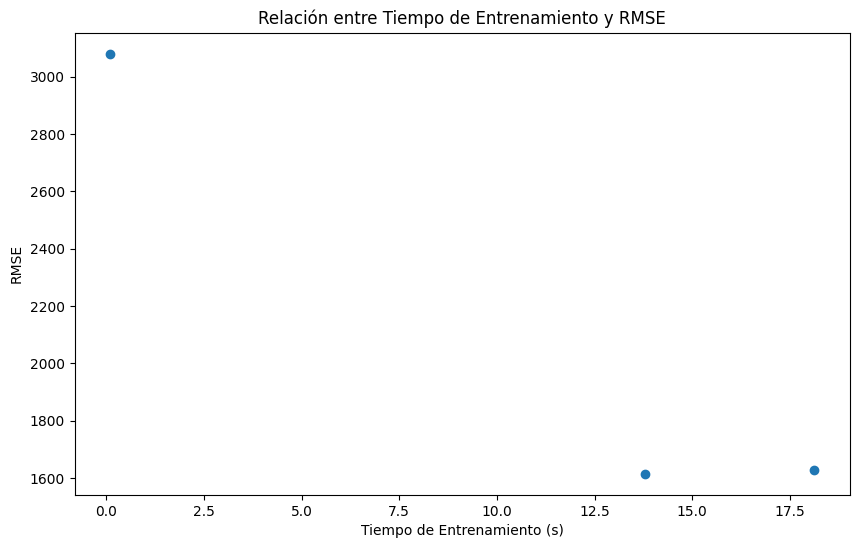

In [ ]:
results_df = pd.DataFrame(results)

print("\nResumen de resultados:")
print(results_df.sort_values(by='RMSE', ascending=True) )

#El mejor modelo puede ser CatBoost, pero es importante considerar otros factores como el tiempo de entrenamiento y la interpretabilidad del modelo antes de tomar una decisión final.

#El mejor modelo calidad / tiempo es cat boost por el momento

# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [ ]  El código no tiene errores- [ ]  Las celdas con el código han sido colocadas en orden de ejecución- [ ]  Los datos han sido descargados y preparados- [ ]  Los modelos han sido entrenados
- [ ]  Se realizó el análisis de velocidad y calidad de los modelos